# Etape 4 — Modelisation
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif de ce notebook, et ce qu'il n'est PAS :**

Ce notebook construit et entraine **3 modeles de nature differente**
(lineaire, arbre, boosting), chacun sous forme d'un **Pipeline scikit-learn
complet** (pretraitement + modele en un seul objet `.fit()`/`.predict()`).
Il compare aussi l'entrainement sur `SalePrice` brut vs `log1p(SalePrice)`.

Ce n'est **pas** encore : le tuning d'hyperparametres (`GridSearchCV`,
etape 5), l'evaluation comparative formelle multi-metriques (MAE/RMSE/R²
avec validation croisee, etape 6), ni l'interpretation des features
(etape 7). Les scores affiches ici sont un **premier apercu** pour
detecter un probleme flagrant (sous-ajustement, surapprentissage), pas un
classement definitif des modeles.

**Decision d'architecture (actee avec l'utilisateur) :** chaque modele est
encapsule dans un Pipeline complet via `build_full_pipeline()`
(`src/preprocessing.py`) : imputation `LotFrontage` + encodage/scaling +
modele, en une seule chaine. Avantage : reutilisable tel quel a l'etape 8
(app Streamlit) via `pipeline.predict(nouvelle_maison_brute)`, sans jamais
rejouer le pretraitement a la main -- donc aucun risque de decalage
train/inference.

## 1. Import des librairies et chargement des donnees

In [9]:
import sys
import time
import numpy as np
import pandas as pd
import joblib
import os

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import os

# --- Detection automatique de l'environnement (local vs Kaggle) -------------
# Objectif : ne JAMAIS avoir a modifier les chemins a la main selon qu'on
# execute ce notebook en local ou dans un Kaggle Notebook. Le meme fichier
# .ipynb tourne tel quel dans les deux cas.
#
# Sur Kaggle, la profondeur exacte sous /kaggle/input varie selon la version
# de l'interface (parfois /kaggle/input/<dataset>/..., parfois
# /kaggle/input/datasets/<dataset>/...) : plutot que de deviner, on
# RECHERCHE directement House_Prices.csv dans toute l'arborescence.
if os.path.exists('/kaggle/input'):
    _dataset_dir = None
    for _root, _dirs, _files in os.walk('/kaggle/input'):
        if 'House_Prices.csv' in _files:
            # _root est .../data/raw -> la racine du dataset est 2 niveaux au-dessus
            _dataset_dir = os.path.dirname(os.path.dirname(_root))
            break

    if _dataset_dir is None:
        raise FileNotFoundError(
            "House_Prices.csv introuvable sous /kaggle/input. Verifie que le "
            "Dataset 'house-prices-project' est bien attache (panneau de droite "
            "-> Input -> Add Input), et que la structure data/raw/House_Prices.csv "
            "a ete preservee lors de l'upload."
        )

    BASE_DATA = f'{_dataset_dir}/data'      # lecture seule (donnees brutes)
    BASE_SRC = f'{_dataset_dir}/src'        # lecture seule (src/preprocessing.py)
    OUTPUT_DIR = '/kaggle/working'          # seul dossier inscriptible sur Kaggle
    print(f"Environnement Kaggle detecte -> dataset = {_dataset_dir}")
else:
    BASE_DATA = '../data'
    BASE_SRC = '..'
    OUTPUT_DIR = '..'
    print("Environnement local detecte")

sys.path.append(BASE_SRC)
from src.preprocessing import run_pipeline, build_full_pipeline

RANDOM_STATE = 42

# On reutilise run_pipeline() pour recuperer les donnees BRUTES (non encodees,
# non imputees pour LotFrontage) -- c'est X_train_raw / X_test_raw qui nous
# interessent ici, pas les arrays deja transformes (X_train / X_test), car
# chaque modele va reconstruire son propre Pipeline complet.
RAW_DATA_PATH = f'{BASE_DATA}/raw/House_Prices.csv'
result = run_pipeline(RAW_DATA_PATH)
X_train_raw = result['X_train_raw']
X_test_raw = result['X_test_raw']
y_train = result['y_train']
y_test = result['y_test']

print('X_train_raw :', X_train_raw.shape)
print('X_test_raw  :', X_test_raw.shape)


Environnement local detecte
X_train_raw : (1166, 87)
X_test_raw  : (292, 87)


**Interpretation :** `X_train_raw`/`X_test_raw` contiennent les donnees
apres nettoyage complet et feature engineering (etapes 1 a 3 : absences
d'equipement codees, `GarageAge`, `TotalSF`, `TotalBath`... deja
presentes), mais **avant** encodage et avant l'imputation de
`LotFrontage` -- c'est volontaire : c'est le Pipeline complet de chaque
modele qui se chargera de ces deux etapes, en les apprenant uniquement sur
le train a chaque `.fit()`.

## 2. Deux cibles a comparer : `SalePrice` brut vs `log1p(SalePrice)`

In [10]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print('SalePrice brut   -> skewness :', round(y_train.skew(), 2))
print('log1p(SalePrice)  -> skewness :', round(y_train_log.skew(), 2))


SalePrice brut   -> skewness : 2.05
log1p(SalePrice)  -> skewness : 0.23


**Interpretation :** confirmation attendue depuis l'etape 1 : la
transformation `log1p` ramene la skewness de `SalePrice` (fortement
asymetrique) vers une distribution beaucoup plus symetrique. Les deux
cibles sont entrainees ci-dessous pour chaque modele ; pour rendre les
scores comparables **en dollars**, les predictions issues d'un modele
entraine sur `log1p(SalePrice)` sont systematiquement re-transformees via
`np.expm1()` avant tout calcul de R².

## 3. Definition des 3 modeles

In [11]:
models = {
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

for name, model in models.items():
    print(f'{name:20s} -> {model}')


Ridge                -> Ridge(random_state=42)
RandomForest         -> RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
GradientBoosting     -> GradientBoostingRegressor(random_state=42)


**Justification du choix (nature differente, comme demande) :**
- **`Ridge`** (regression lineaire regularisee) plutot qu'une
  `LinearRegression` classique : la colinearite entre variables de surface
  deja identifiee a l'etape 2 (`TotalSF`/`GrLivArea`/`TotalBsmtSF`...) rend
  une regression lineaire non regularisee instable (coefficients qui
  peuvent s'affoler en presence de variables fortement correlees entre
  elles). `Ridge` corrige ca directement via son terme de penalisation
  (`alpha`), tout en gardant l'interet principal d'un modele lineaire :
  des coefficients directement interpretables. `alpha=1.0` est la valeur
  par defaut ici -- son reglage fin (`GridSearchCV`) viendra a l'etape 5.
- **`RandomForestRegressor`** : base sur des arbres, invariant a l'echelle
  des variables, capture nativement des interactions (ex. quartier x
  surface) sans les specifier a la main.
- **`GradientBoostingRegressor`** : boosting sequentiel, generalement le
  plus performant sur des donnees tabulaires de cette taille ; plus lent a
  entrainer et plus sensible aux hyperparametres (raison de plus pour
  reserver son reglage fin a l'etape 5).

## 4. Entrainement : 3 modeles x 2 cibles = 6 pipelines

In [12]:
results = []
fitted_pipelines = {}

for model_name, model in models.items():
    for target_name, y_tr, y_te, is_log in [
        ('brute', y_train, y_test, False),
        ('log1p', y_train_log, y_test_log, True),
    ]:
        pipeline = build_full_pipeline(model, X_train_raw)

        start = time.time()
        pipeline.fit(X_train_raw, y_tr)
        fit_time = time.time() - start

        pred_train = pipeline.predict(X_train_raw)
        pred_test = pipeline.predict(X_test_raw)

        if is_log:
            # Retour en dollars pour comparer sur la meme echelle que la cible brute
            pred_train_dollars = np.expm1(pred_train)
            pred_test_dollars = np.expm1(pred_test)
        else:
            pred_train_dollars = pred_train
            pred_test_dollars = pred_test

        r2_train = r2_score(y_train, pred_train_dollars)
        r2_test = r2_score(y_test, pred_test_dollars)
        mae_train = mean_absolute_error(y_train, pred_train_dollars)
        mae_test = mean_absolute_error(y_test, pred_test_dollars)
        rmse_train = root_mean_squared_error(y_train, pred_train_dollars)
        rmse_test = root_mean_squared_error(y_test, pred_test_dollars)

        results.append({
            'Modele': model_name,
            'Cible': target_name,
            'R2 train': round(r2_train, 3),
            'R2 test': round(r2_test, 3),
            'Ecart R2 (train-test)': round(r2_train - r2_test, 3),
            'MAE train ($)': round(mae_train, 0),
            'MAE test ($)': round(mae_test, 0),
            'RMSE train ($)': round(rmse_train, 0),
            'RMSE test ($)': round(rmse_test, 0),
            'Temps fit (s)': round(fit_time, 2),
        })
        fitted_pipelines[f'{model_name}_{target_name}'] = pipeline

results_df = pd.DataFrame(results).sort_values('R2 test', ascending=False).reset_index(drop=True)
results_df


,Modele,Cible,R2 train,R2 test,Ecart R2 (train-test),MAE train ($),MAE test ($),RMSE train ($),RMSE test ($),Temps fit (s)
0,GradientBoosting,brute,0.975,0.924,0.052,9401.0,14650.0,12637.0,20554.0,0.91
1,Ridge,log1p,0.959,0.923,0.036,11083.0,14670.0,16375.0,20663.0,0.07
2,GradientBoosting,log1p,0.970,0.923,0.047,9732.0,14422.0,13907.0,20593.0,0.87
3,RandomForest,log1p,0.985,0.905,0.079,6114.0,15760.0,10019.0,22855.0,0.55
4,RandomForest,brute,0.985,0.900,0.085,6138.0,15750.0,9938.0,23516.0,0.58
5,Ridge,brute,0.931,0.880,0.052,15014.0,18777.0,21166.0,25797.0,0.12


**Interpretation (premier apercu, a confirmer par la validation croisee de
l'etape 5) :**
- `R2`, `MAE` et `RMSE` sont tous calcules **en dollars** dans tous les cas
  (predictions `log1p` re-transformees via `expm1`), donc les 6 lignes sont
  bien comparables entre elles.
- **MAE** (erreur absolue moyenne) donne l'erreur "typique" en dollars,
  facile a interpreter ("le modele se trompe en moyenne de X $"). **RMSE**
  penalise davantage les grosses erreurs (utile car quelques logements
  haut de gamme, cf. etape 2, peuvent generer de grosses erreurs isolees).
  **R²** reste le plus facile a comparer entre modeles (0 a 1, part de
  variance expliquee).
- **Sur le surapprentissage** : attention au vocabulaire -- ce qu'on
  regarde ici (`Ecart R2 (train-test)`, ou l'ecart MAE/RMSE train vs test)
  est une **difference** entre deux scores sur un seul split, pas un
  **ecart-type** au sens statistique (qui mesurerait la dispersion d'un
  score autour de sa moyenne sur plusieurs mesures, ex. plusieurs folds de
  validation croisee). Un grand ecart train-test ici est un indice de
  surapprentissage potentiel (attendu plutot pour `RandomForest`/
  `GradientBoosting` que pour la regression lineaire, plus contrainte),
  mais ce n'est qu'un signal sur **un seul split** -- pas encore la mesure
  robuste (moyenne +/- ecart-type sur plusieurs folds) que produira la
  validation croisee de l'etape 5.

## 5. Comparaison visuelle rapide

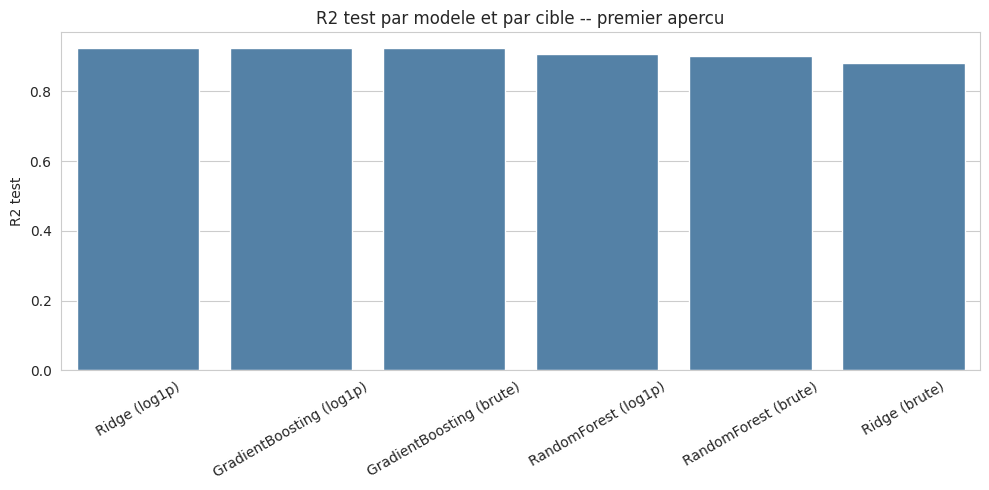

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.copy()
plot_df['label'] = plot_df['Modele'] + ' (' + plot_df['Cible'] + ')'

sns.barplot(data=plot_df, x='label', y='R2 test', ax=ax, color='steelblue')
ax.set_title("R2 test par modele et par cible -- premier apercu")
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 6. Sauvegarde des pipelines entraines

In [6]:
os.makedirs(f'{OUTPUT_DIR}/models', exist_ok=True)

for key, pipeline in fitted_pipelines.items():
    path = f'{OUTPUT_DIR}/models/{key}.joblib'
    joblib.dump(pipeline, path)

print(f'{len(fitted_pipelines)} pipelines sauvegardes dans models/ :')
for key in fitted_pipelines:
    print(' -', f'{key}.joblib')


6 pipelines sauvegardes dans models/ :
 - Ridge_brute.joblib
 - Ridge_log1p.joblib
 - RandomForest_brute.joblib
 - RandomForest_log1p.joblib
 - GradientBoosting_brute.joblib
 - GradientBoosting_log1p.joblib


**Interpretation :** chaque fichier `.joblib` contient un Pipeline
**complet** (imputation `LotFrontage` + encodage/scaling + modele), deja
fit. N'importe lequel peut etre recharge et applique directement a une
nouvelle maison brute (apres nettoyage + feature engineering, cf. etapes 1
et 3) sans code de pretraitement supplementaire -- c'est cette propriete
qui sera exploitee par l'app Streamlit (etape 8).

## Conclusion de l'etape 4

- 3 modeles de nature differente (lineaire, arbre, boosting) ont ete
  entraines, chacun sur `SalePrice` brut et sur `log1p(SalePrice)`, soit
  6 Pipelines complets et directement reutilisables.
- Chaque Pipeline encapsule tout le pretraitement (imputation
  `LotFrontage` + encodage + scaling) et le modele en un seul objet
  `.fit()`/`.predict()` -- decision actee avec l'utilisateur pour
  simplifier l'etape 8 (app Streamlit) et eliminer tout risque de
  decalage entre l'entrainement et l'inference.
- Premier apercu des scores (R² sur un seul split, en dollars) disponible
  dans `results_df`, mais **non definitif** : ni validation croisee, ni
  tuning d'hyperparametres, ni metriques MAE/RMSE n'ont ete faits ici.
- Les 6 pipelines entraines sont sauvegardes dans `models/` pour etre
  repris directement aux etapes suivantes, sans reentrainement.

**Prochaine etape (etape 5) :** validation croisee (`KFold`,
`cross_val_score`) et recherche d'hyperparametres (`GridSearchCV`) pour
chacun des 3 modeles, afin d'obtenir une estimation fiable de leur
performance et de choisir serieusement entre cible brute et `log1p`,
avant l'evaluation comparative formelle (etape 6).